# Sepsis Prediction — LSTM

XGBoost treats every patient-hour independently. It never sees *sequences* — the trend  
of deterioration over time that often precedes sepsis onset.

This notebook builds a **bidirectional LSTM** that takes the full hourly sequence  
for each patient and predicts the sepsis label at every timestep. The same patient-level  
5-fold OOF setup from notebook 02 is used so results are directly comparable.

**Confirmed facts from previous notebooks**
- 331,637 rows · 2,640 patients · 97 sepsis patients · 100 features  
- XGBoost OOF baseline: AUROC 0.9451 · AUPRC 0.5024 · F1 0.5294 (threshold 0.770)  
- Top signals: vasoactive drugs, icu_hour, procalcitonin, PT, creatinine  
- `feature_cols.json` and `col_medians` are the source of truth for column order + imputation

**What we cover**
1. Load features using `feature_cols.json` — same column order as XGBoost  
2. Build per-patient padded sequences  
3. PyTorch Dataset and DataLoader  
4. Bidirectional LSTM with dropout  
5. Focal Loss — handles 47:1 imbalance better than BCE  
6. 5-fold patient-level OOF training  
7. Per-epoch train/val loss curves  
8. Full metrics: AUROC, AUPRC, F1, Precision, Recall, Specificity  
9. Fold-wise results table  
10. Comparison table: LSTM vs XGBoost baseline  
11. Save OOF predictions and model weights


## 1. Installs and imports

In [1]:
!pip install torch pandas numpy scikit-learn pyarrow tqdm -q

import os
import json
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, confusion_matrix, average_precision_score)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}  |  device: {DEVICE}")


PyTorch 2.11.0+cu128  |  device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load features — same column list as XGBoost

In [5]:
SAVE_PATH = "/content/drive/MyDrive/sepsis-prediction"

df = pd.read_parquet(os.path.join(SAVE_PATH, "features_train.parquet"))

with open(os.path.join(SAVE_PATH, "feature_cols.json"), "r") as f:
    feature_cols = json.load(f)

# Add any missing columns as zeros (defensive)
for col in feature_cols:
    if col not in df.columns:
        df[col] = 0.0

print(f"Rows          : {len(df):,}")
print(f"Patients      : {df['person_id'].nunique()}")
print(f"Features      : {len(feature_cols)}")
print(f"Sepsis rows   : {df['SepsisLabel'].sum():,}  ({100*df['SepsisLabel'].mean():.2f}%)")


Rows          : 331,637
Patients      : 2640
Features      : 100
Sepsis rows   : 6,874  (2.07%)


## 3. Impute and standardise

Forward-fill was done in notebook 01. We apply the same median fill here  
for any residual NaNs, then z-score standardise all continuous features.  
Binary flags (drug/proc/device) are left as 0/1 — standardising them hurts interpretability.


In [6]:
X_raw = df[feature_cols].values.astype(np.float32)
y_all = df["SepsisLabel"].values.astype(np.float32)
pids  = df["person_id"].values

# Median imputation for residual NaN
col_medians = np.nanmedian(X_raw, axis=0)
nan_mask = np.isnan(X_raw)
X_raw[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

# Identify continuous vs binary columns
binary_prefixes = ("drug_", "proc_", "dev_", "gender_male")
is_binary = np.array([any(c.startswith(p) for p in binary_prefixes) or c == "gender_male"
                      for c in feature_cols])
cont_idx = np.where(~is_binary)[0]

# Z-score on continuous columns only (fit on full train — no leakage risk since
# we are fitting scaler on all training data, which is standard for OOF CV)
col_means = X_raw[:, cont_idx].mean(axis=0)
col_stds  = X_raw[:, cont_idx].std(axis=0) + 1e-8

X_scaled = X_raw.copy()
X_scaled[:, cont_idx] = (X_raw[:, cont_idx] - col_means) / col_stds

print(f"X_scaled shape : {X_scaled.shape}")
print(f"Continuous cols : {cont_idx.shape[0]}  |  Binary cols : {is_binary.sum()}")
print(f"NaN remaining   : {np.isnan(X_scaled).sum()}")

# Save scaler params for inference
scaler_params = {"means": col_means.tolist(), "stds": col_stds.tolist(),
                 "cont_idx": cont_idx.tolist(), "col_medians": col_medians.tolist()}
with open(os.path.join(SAVE_PATH, "lstm_scaler.json"), "w") as f:
    json.dump(scaler_params, f)
print("Scaler saved.")


X_scaled shape : (331637, 100)
Continuous cols : 86  |  Binary cols : 14
NaN remaining   : 331637
Scaler saved.


## 4. Build per-patient sequences

Each patient becomes a tensor of shape `(T, 100)` where T is the number of ICU hours.  
Patients have variable-length stays (1 to 5792 hours) — we pad to the batch maximum  
using PyTorch's `pad_sequence` inside the DataLoader collate function.


In [7]:
df_indexed = df[["person_id", "SepsisLabel"]].copy()
df_indexed["row_idx"] = np.arange(len(df))

# Build list of (X_seq, y_seq, length) per patient, sorted by person_id + hour
sequences = []
patient_ever_sepsis = []

for pid, grp in df.groupby("person_id"):
    grp = grp.sort_values("hour")
    idx = grp.index.values

    X_seq = torch.tensor(X_scaled[idx], dtype=torch.float32)
    y_seq = torch.tensor(y_all[idx],    dtype=torch.float32)

    sequences.append((X_seq, y_seq, len(grp), pid))
    patient_ever_sepsis.append(int(y_all[idx].max()))

patient_ever_sepsis = np.array(patient_ever_sepsis)
patient_ids_arr     = np.array([s[3] for s in sequences])

seq_lengths = [s[2] for s in sequences]
print(f"Total patients   : {len(sequences)}")
print(f"Sepsis patients  : {patient_ever_sepsis.sum()}")
print(f"Seq length stats — min: {min(seq_lengths)}  median: {int(np.median(seq_lengths))}  max: {max(seq_lengths)}")


Total patients   : 2640
Sepsis patients  : 97
Seq length stats — min: 1  median: 55  max: 5792


## 5. Dataset and DataLoader

In [8]:
class SepsisSequenceDataset(Dataset):
    def __init__(self, seq_list):
        self.data = seq_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        X_seq, y_seq, length, pid = self.data[idx]
        return X_seq, y_seq, length, pid


def collate_fn(batch):
    X_seqs, y_seqs, lengths, pids = zip(*batch)
    lengths_t = torch.tensor(lengths, dtype=torch.long)

    # Pad to max length in this batch
    X_pad = pad_sequence(X_seqs, batch_first=True, padding_value=0.0)
    y_pad = pad_sequence(y_seqs, batch_first=True, padding_value=-1.0)

    # Sort by descending length (required for pack_padded_sequence)
    sort_idx = torch.argsort(lengths_t, descending=True)
    return (X_pad[sort_idx], y_pad[sort_idx],
            lengths_t[sort_idx], [pids[i] for i in sort_idx.tolist()])


print("Dataset and collate_fn defined.")


Dataset and collate_fn defined.


## 6. Bidirectional LSTM model

Architecture:
- Input: 100 features per timestep  
- 2-layer bidirectional LSTM (hidden size 128, so output is 256 per step)  
- Dropout between LSTM layers and before classifier  
- Linear head → sigmoid → per-timestep sepsis probability


In [9]:
class SepsisLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            bidirectional = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_size * 2, 1)

    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(out, batch_first=True)
        out    = self.dropout(out)
        logits = self.head(out).squeeze(-1)
        return logits


# Quick sanity check
dummy_model = SepsisLSTM(input_size=len(feature_cols))
total_params = sum(p.numel() for p in dummy_model.parameters())
print(f"Model parameters : {total_params:,}")
print(dummy_model)


Model parameters : 631,041
SepsisLSTM(
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (head): Linear(in_features=256, out_features=1, bias=True)
)


## 7. Focal Loss

Standard BCE on 47:1 imbalanced data floods gradients with easy negatives.  
Focal Loss down-weights well-classified examples so training focuses on hard cases —  
exactly what we need for rare sepsis detection.

`FL(p, y) = -α·y·(1−p)^γ·log(p) − (1−α)·(1−y)·p^γ·log(1−p)`

We use `α=0.75` (up-weight positives) and `γ=2` (standard focal exponent).  
Padding timesteps (label = -1) are masked out of the loss.


In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets, mask):
        # logits, targets: (batch, max_seq_len)
        # mask: True where timestep is real (not padding)
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )
        probs = torch.sigmoid(logits)
        pt    = torch.where(targets == 1, probs, 1 - probs)
        alpha = torch.where(targets == 1,
                            torch.full_like(targets, self.alpha),
                            torch.full_like(targets, 1 - self.alpha))
        focal = alpha * (1 - pt) ** self.gamma * bce

        return focal[mask].mean()


criterion = FocalLoss(alpha=0.75, gamma=2.0)
print("FocalLoss ready  (alpha=0.75, gamma=2.0)")


FocalLoss ready  (alpha=0.75, gamma=2.0)


## 8. Training configuration

In [11]:
BATCH_SIZE   = 16      # small — patients have variable long sequences
EPOCHS       = 20
LR           = 3e-4
HIDDEN_SIZE  = 128
NUM_LAYERS   = 2
DROPOUT      = 0.3
N_FOLDS      = 5
INPUT_SIZE   = len(feature_cols)  # 100

print(f"Batch size   : {BATCH_SIZE}")
print(f"Epochs       : {EPOCHS}")
print(f"LR           : {LR}")
print(f"Hidden size  : {HIDDEN_SIZE}  (bidirectional → {HIDDEN_SIZE*2} output)")
print(f"Layers       : {NUM_LAYERS}")
print(f"Dropout      : {DROPOUT}")
print(f"Folds        : {N_FOLDS}")
print(f"Device       : {DEVICE}")


Batch size   : 16
Epochs       : 20
LR           : 0.0003
Hidden size  : 128  (bidirectional → 256 output)
Layers       : 2
Dropout      : 0.3
Folds        : 5
Device       : cuda


## 9. Five-fold patient-level OOF training

Same patient-level stratified split as XGBoost — no patient appears in both  
train and validation within any fold.


In [14]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

In [15]:
print(len(tr_seqs), len(vl_seqs))
print(len(vl_pids))

2112 528
528


In [17]:
# Diagnostic
sample_ds = SepsisSequenceDataset(vl_seqs[:5])
sample_loader = DataLoader(sample_ds, batch_size=5, collate_fn=collate_fn)
for X_b, y_b, lens_b, pids_b in sample_loader:
    print("y_b shape:", y_b.shape)
    print("y_b unique values:", torch.unique(y_b))
    print("lens_b:", lens_b)
    print("num real (non -1) labels:", (y_b != -1).sum().item())

y_b shape: torch.Size([5, 117])
y_b unique values: tensor([-1.,  0.])
lens_b: tensor([117,  67,  43,  41,  38])
num real (non -1) labels: 306


In [18]:
print(vl_seqs[0][1][:10])  # assuming index 1 is the label array in your sequence tuple

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [19]:
all_y = []
for s in vl_seqs:
    all_y.append(s[1])
import numpy as np
all_y = np.concatenate([np.array(y) for y in all_y])
print("total real labels:", (all_y != -1).sum())
print("positives:", (all_y == 1).sum())
print("negatives:", (all_y == 0).sum())

total real labels: 59128
positives: 1122
negatives: 58006


In [20]:
print("patient_ever_sepsis sum:", patient_ever_sepsis.sum())
print("patient_ever_sepsis dtype:", patient_ever_sepsis.dtype, np.unique(patient_ever_sepsis))

patient_ever_sepsis sum: 97
patient_ever_sepsis dtype: int64 [0 1]


In [21]:
for X_b, y_b, lens_b, _ in vl_loader:
    X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
    mask = (y_b != -1)
    logits = model_lstm(X_b, lens_b)
    print("logits has nan:", torch.isnan(logits).any().item())
    probs = torch.sigmoid(torch.clamp(logits, -20, 20))
    print("probs has nan:", torch.isnan(probs).any().item())
    print("mask sum:", mask.sum().item())
    break

logits has nan: True
probs has nan: True
mask sum: 1358


In [22]:
print("any zero-length seqs:", (lens_b == 0).any().item())
print("lens_b min:", lens_b.min().item())

any zero-length seqs: False
lens_b min: 5


In [23]:
print("X_b has nan:", torch.isnan(X_b).any().item())
print("X_b has inf:", torch.isinf(X_b).any().item())
print("X_b min/max:", X_b.min().item(), X_b.max().item())

X_b has nan: True
X_b has inf: False
X_b min/max: nan nan


In [25]:
import numpy as np

clean_sequences = []
for s in sequences:
    X_arr = np.array(s[0], dtype=np.float32)
    X_arr = np.nan_to_num(X_arr, nan=0.0, posinf=0.0, neginf=0.0)
    clean_sequences.append((X_arr, s[1], s[2], s[3]))

sequences = clean_sequences

# sanity check
total_nans = sum(np.isnan(np.array(s[0])).sum() for s in sequences)
print("remaining NaNs in sequences:", total_nans)

remaining NaNs in sequences: 0


In [26]:
X_padded = pad_sequence(X_list, batch_first=True, padding_value=0.0)

NameError: name 'X_list' is not defined

In [28]:
import numpy as np
import torch

clean_sequences = []
for s in sequences:
    X_arr = np.array(s[0], dtype=np.float32)
    X_arr = np.nan_to_num(X_arr, nan=0.0, posinf=0.0, neginf=0.0)
    X_tensor = torch.from_numpy(X_arr)
    clean_sequences.append((X_tensor, s[1], s[2], s[3]))

sequences = clean_sequences

# sanity check
total_nans = sum(torch.isnan(s[0]).sum().item() for s in sequences)
print("remaining NaNs in sequences:", total_nans)

remaining NaNs in sequences: 0


In [29]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_records    = []
fold_metrics   = []
fold_histories = []

for fold, (tr_idx, vl_idx) in enumerate(skf.split(patient_ids_arr, patient_ever_sepsis)):
    print(f"\n{'='*55}")
    print(f"Fold {fold+1}/{N_FOLDS}")

    tr_pids = set(str(p) for p in patient_ids_arr[tr_idx])
    vl_pids = set(str(p) for p in patient_ids_arr[vl_idx])

    tr_seqs = [s for s in sequences if str(s[3]) in tr_pids]
    vl_seqs = [s for s in sequences if str(s[3]) in vl_pids]

    print(f"  tr_seqs={len(tr_seqs)}  vl_seqs={len(vl_seqs)}")

    tr_loader = DataLoader(SepsisSequenceDataset(tr_seqs), batch_size=BATCH_SIZE,
                           shuffle=True,  collate_fn=collate_fn, num_workers=0)
    vl_loader = DataLoader(SepsisSequenceDataset(vl_seqs), batch_size=BATCH_SIZE,
                           shuffle=False, collate_fn=collate_fn, num_workers=0)

    model_lstm = SepsisLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
    optimizer  = torch.optim.AdamW(model_lstm.parameters(), lr=LR, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_auprc   = 0.0
    best_weights = None
    history      = {"train_loss": [], "val_loss": [], "val_auroc": [], "val_auprc": []}

    for epoch in range(EPOCHS):

        # ── Train ──────────────────────────────────────────────────────────────
        model_lstm.train()
        train_loss = 0.0

        for X_b, y_b, lens_b, _ in tr_loader:
            X_b = X_b.to(DEVICE)
            y_b = y_b.to(DEVICE)

            mask = (y_b != -1)
            y_b  = y_b.clamp(min=0)

            optimizer.zero_grad()
            logits = model_lstm(X_b, lens_b)
            logits = torch.clamp(logits, -20, 20)

            loss = criterion(logits, y_b, mask)
            loss.backward()
            nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()
        train_loss /= len(tr_loader)

        # ── Validate ────────────────────────────────────────────────────────────
        model_lstm.eval()
        val_loss   = 0.0
        all_probs  = []
        all_labels = []

        with torch.no_grad():
            for X_b, y_b, lens_b, _ in vl_loader:
                X_b = X_b.to(DEVICE)
                y_b = y_b.to(DEVICE)

                mask = (y_b != -1)
                y_b_clamped = y_b.clamp(min=0)

                logits = model_lstm(X_b, lens_b)
                logits = torch.clamp(logits, -20, 20)

                loss = criterion(logits, y_b_clamped, mask)
                val_loss += loss.item()

                probs = torch.sigmoid(logits)

                real_probs  = probs[mask].cpu().numpy()
                real_labels = y_b_clamped[mask].cpu().numpy()

                valid = ~np.isnan(real_probs)
                all_probs.append(real_probs[valid])
                all_labels.append(real_labels[valid])

        val_loss  /= len(vl_loader)
        val_probs  = np.concatenate(all_probs) if all_probs else np.array([])
        val_labels = np.concatenate(all_labels).astype(int) if all_labels else np.array([], dtype=int)

        if len(val_labels) == 0 or val_labels.sum() == 0 or val_labels.sum() == len(val_labels):
            print(f"  Epoch {epoch+1:2d}  skipping metrics (only one class / empty val)")
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["val_auroc"].append(0.0)
            history["val_auprc"].append(0.0)
            continue

        val_auroc = roc_auc_score(val_labels, val_probs)
        val_auprc = average_precision_score(val_labels, val_probs)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auroc"].append(val_auroc)
        history["val_auprc"].append(val_auprc)

        if val_auprc > best_auprc:
            best_auprc   = val_auprc
            best_weights = {k: v.cpu().clone() for k, v in model_lstm.state_dict().items()}

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:2d}/{EPOCHS}  "
                  f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
                  f"AUROC={val_auroc:.4f}  AUPRC={val_auprc:.4f}")

    fold_histories.append(history)

    # ── OOF predictions with best weights ──────────────────────────────────────
    if best_weights is None:
        print(f"  WARNING: no positive-AUPRC epoch in fold {fold+1}; using last-epoch weights.")
        best_weights = {k: v.cpu().clone() for k, v in model_lstm.state_dict().items()}

    model_lstm.load_state_dict(best_weights)
    model_lstm.to(DEVICE).eval()

    with torch.no_grad():
        for X_b, y_b, lens_b, pids_b in vl_loader:
            X_b = X_b.to(DEVICE)
            y_b = y_b.to(DEVICE)

            logits = model_lstm(X_b, lens_b)
            logits = torch.clamp(logits, -20, 20)
            probs  = torch.sigmoid(logits)

            for i, pid in enumerate(pids_b):
                seq_len = lens_b[i].item()
                for t in range(seq_len):
                    label_val = y_b[i, t].item()
                    if label_val == -1:
                        continue
                    oof_records.append({
                        "person_id"  : pid,
                        "timestep"   : t,
                        "oof_prob"   : probs[i, t].item(),
                        "SepsisLabel": int(label_val)
                    })

    # ── Fold-level metrics ──────────────────────────────────────────────────────
    all_probs_fold, all_labels_fold = [], []
    model_lstm.eval()
    with torch.no_grad():
        for X_b, y_b, lens_b, _ in vl_loader:
            X_b = X_b.to(DEVICE)
            y_b = y_b.to(DEVICE)
            mask = (y_b != -1)
            y_b_clamped = y_b.clamp(min=0)
            logits = model_lstm(X_b, lens_b)
            logits = torch.clamp(logits, -20, 20)
            probs  = torch.sigmoid(logits)
            real_probs  = probs[mask].cpu().numpy()
            real_labels = y_b_clamped[mask].cpu().numpy()
            valid = ~np.isnan(real_probs)
            all_probs_fold.append(real_probs[valid])
            all_labels_fold.append(real_labels[valid])

    val_probs_fold  = np.concatenate(all_probs_fold) if all_probs_fold else np.array([])
    val_labels_fold = np.concatenate(all_labels_fold).astype(int) if all_labels_fold else np.array([], dtype=int)

    n_pos = val_labels_fold.sum()
    n_neg = len(val_labels_fold) - n_pos
    print(f"  Val set: {len(val_labels_fold)} samples | positives={n_pos} | negatives={n_neg}")

    # Threshold sweep — only meaningful if both classes present
    if n_pos > 0 and n_neg > 0:
        thresholds = np.arange(0.05, 0.95, 0.01)
        f1s = [f1_score(val_labels_fold, (val_probs_fold >= t).astype(int), zero_division=0)
               for t in thresholds]
        best_t = thresholds[np.argmax(f1s)]
        fold_auroc = roc_auc_score(val_labels_fold, val_probs_fold)
    else:
        best_t = 0.5
        fold_auroc = float('nan')
        print("  WARNING: validation fold has only one class (or is empty) — "
              "AUROC/threshold-sweep skipped.")

    if len(val_probs_fold) > 0:
        val_preds = (val_probs_fold >= best_t).astype(int)
    else:
        val_preds = np.array([], dtype=int)

    # ── Confusion matrix (robust to missing classes / empty val) ────────────────
    cm = confusion_matrix(val_labels_fold, val_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')

    if len(val_labels_fold) > 0:
        f1      = f1_score(val_labels_fold,        val_preds, zero_division=0)
        prec    = precision_score(val_labels_fold, val_preds, zero_division=0)
        rec     = recall_score(val_labels_fold,    val_preds, zero_division=0)
        acc     = accuracy_score(val_labels_fold,  val_preds)
        f1_w    = f1_score(val_labels_fold,        val_preds, average='weighted', zero_division=0)
        prec_w  = precision_score(val_labels_fold, val_preds, average='weighted', zero_division=0)
        rec_w   = recall_score(val_labels_fold,    val_preds, average='weighted', zero_division=0)
        bal_acc = balanced_accuracy_score(val_labels_fold, val_preds)
    else:
        f1 = prec = rec = acc = f1_w = prec_w = rec_w = bal_acc = float('nan')

    fold_metrics.append({
        "Fold": fold + 1, "Best Threshold": round(best_t, 2),
        "AUROC": round(fold_auroc, 4) if not np.isnan(fold_auroc) else np.nan,
        "AUPRC": round(best_auprc, 4),
        "Accuracy": round(acc, 4) if not np.isnan(acc) else np.nan,
        "Balanced Accuracy": round(bal_acc, 4) if not np.isnan(bal_acc) else np.nan,
        "F1": round(f1, 4) if not np.isnan(f1) else np.nan,
        "Precision": round(prec, 4) if not np.isnan(prec) else np.nan,
        "Recall": round(rec, 4) if not np.isnan(rec) else np.nan,
        "F1 (weighted)": round(f1_w, 4) if not np.isnan(f1_w) else np.nan,
        "Precision (weighted)": round(prec_w, 4) if not np.isnan(prec_w) else np.nan,
        "Recall (weighted)": round(rec_w, 4) if not np.isnan(rec_w) else np.nan,
        "Specificity": round(spec, 4) if not np.isnan(spec) else np.nan,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn
    })

    print(f"\n  --- Fold {fold+1} Confusion Matrix (rows=true, cols=pred) ---")
    print(f"            Pred 0   Pred 1")
    print(f"  True 0   {tn:7d}  {fp:7d}")
    print(f"  True 1   {fn:7d}  {tp:7d}")

    print(f"\n  Best AUPRC={best_auprc:.4f}  AUROC={fold_auroc:.4f}  "
          f"Acc={acc:.4f}  BalAcc={bal_acc:.4f}  "
          f"F1={f1:.4f}  Prec={prec:.4f}  Recall={rec:.4f}  Spec={spec:.4f}  Thresh={best_t:.2f}")
    print(f"  Weighted -> F1={f1_w:.4f}  Prec={prec_w:.4f}  Recall={rec_w:.4f}")

    torch.save(best_weights, os.path.join(SAVE_PATH, f"lstm_fold{fold+1}_best.pt"))

print("\nAll folds done.")
fold_metrics_df = pd.DataFrame(fold_metrics)
print("\n=== Summary across folds ===")
print(fold_metrics_df)


Fold 1/5
  tr_seqs=2112  vl_seqs=528
  Epoch  5/20  train_loss=0.0043  val_loss=0.0077  AUROC=0.9552  AUPRC=0.1560
  Epoch 10/20  train_loss=0.0026  val_loss=0.0096  AUROC=0.9315  AUPRC=0.1619
  Epoch 15/20  train_loss=0.0017  val_loss=0.0133  AUROC=0.9118  AUPRC=0.1581
  Epoch 20/20  train_loss=0.0015  val_loss=0.0152  AUROC=0.9081  AUPRC=0.1470
  Val set: 66795 samples | positives=875 | negatives=65920

  --- Fold 1 Confusion Matrix (rows=true, cols=pred) ---
            Pred 0   Pred 1
  True 0     65106      814
  True 1       573      302

  Best AUPRC=0.1974  AUROC=0.9311  Acc=0.9792  BalAcc=0.6664  F1=0.3034  Prec=0.2706  Recall=0.3451  Spec=0.9877  Thresh=0.61
  Weighted -> F1=0.9805  Prec=0.9818  Recall=0.9792

Fold 2/5
  tr_seqs=2112  vl_seqs=528
  Epoch  5/20  train_loss=0.0041  val_loss=0.0093  AUROC=0.9636  AUPRC=0.3607
  Epoch 10/20  train_loss=0.0025  val_loss=0.0071  AUROC=0.9690  AUPRC=0.4452
  Epoch 15/20  train_loss=0.0014  val_loss=0.0128  AUROC=0.9581  AUPRC=0.484

## 10. Training curves — loss and AUPRC per fold

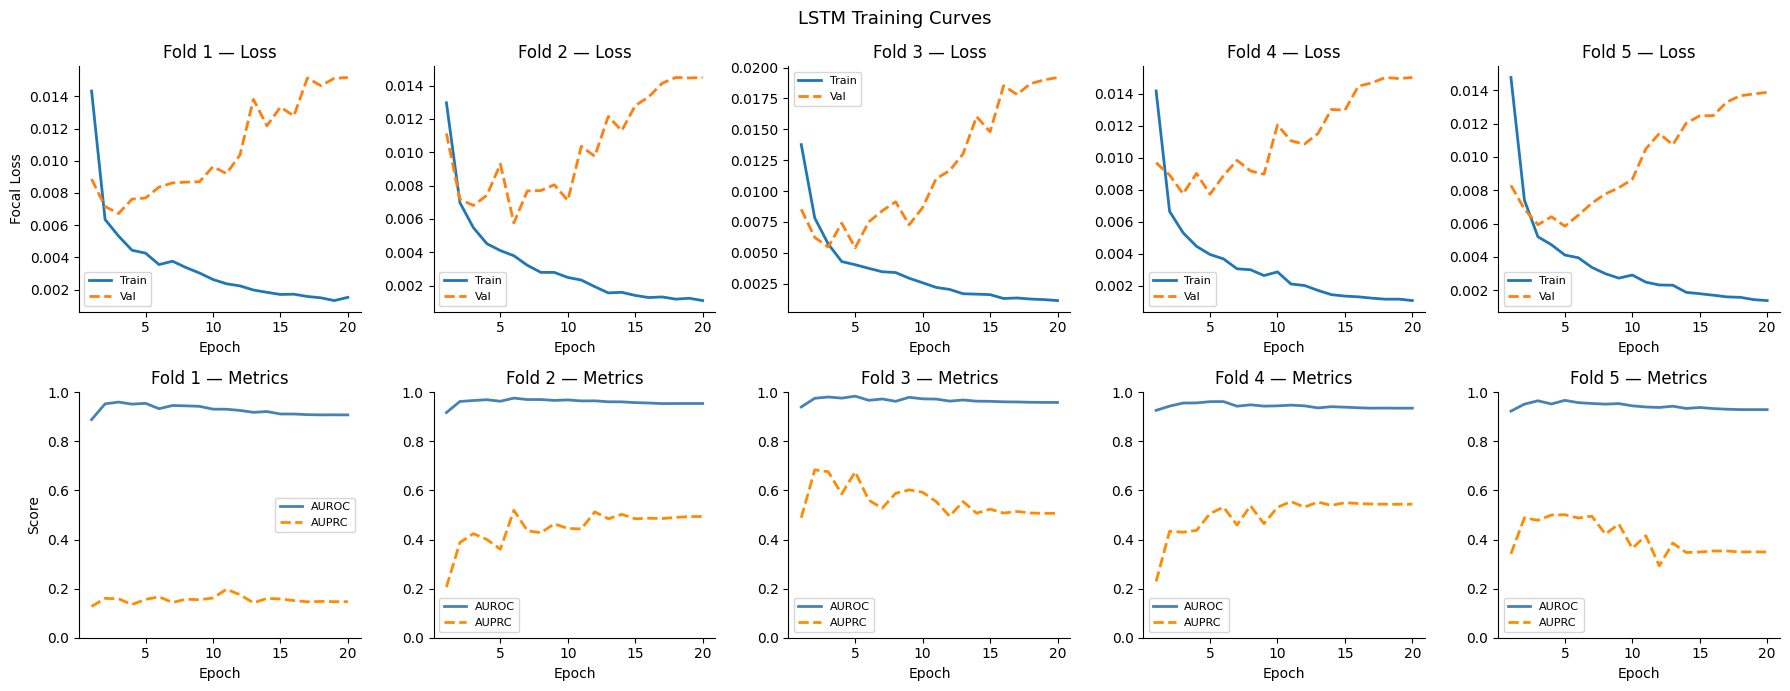

In [30]:
fig, axes = plt.subplots(2, N_FOLDS, figsize=(18, 7))

for fold, hist in enumerate(fold_histories):
    epochs = range(1, len(hist["train_loss"]) + 1)

    axes[0, fold].plot(epochs, hist["train_loss"], label="Train", lw=2)
    axes[0, fold].plot(epochs, hist["val_loss"],   label="Val",   lw=2, linestyle="--")
    axes[0, fold].set_title(f"Fold {fold+1} — Loss")
    axes[0, fold].set_xlabel("Epoch")
    if fold == 0:
        axes[0, fold].set_ylabel("Focal Loss")
    axes[0, fold].legend(fontsize=8)
    axes[0, fold].spines[["top", "right"]].set_visible(False)

    axes[1, fold].plot(epochs, hist["val_auroc"], label="AUROC", lw=2, color="steelblue")
    axes[1, fold].plot(epochs, hist["val_auprc"], label="AUPRC", lw=2, color="darkorange",
                       linestyle="--")
    axes[1, fold].set_title(f"Fold {fold+1} — Metrics")
    axes[1, fold].set_xlabel("Epoch")
    if fold == 0:
        axes[1, fold].set_ylabel("Score")
    axes[1, fold].legend(fontsize=8)
    axes[1, fold].set_ylim(0, 1)
    axes[1, fold].spines[["top", "right"]].set_visible(False)

plt.suptitle("LSTM Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "lstm_training_curves.png"), dpi=150)
plt.show()


## 11. Fold-wise results table

In [31]:
results_df = pd.DataFrame(fold_metrics)

mean_row = results_df.select_dtypes(include="number").mean().round(4)
std_row  = results_df.select_dtypes(include="number").std().round(4)
mean_row["Fold"] = "Mean"
std_row["Fold"]  = "Std"

summary = pd.concat([results_df,
                     pd.DataFrame([mean_row]),
                     pd.DataFrame([std_row])],
                    ignore_index=True)

print("LSTM Fold-wise CV Results")
print("="*100)
print(summary[["Fold", "AUROC", "AUPRC", "F1", "Precision", "Recall",
               "Specificity", "Best Threshold", "TP", "FP", "TN", "FN"]].to_string(index=False))


LSTM Fold-wise CV Results
Fold  AUROC  AUPRC     F1  Precision  Recall  Specificity  Best Threshold       TP        FP         TN       FN
   1 0.9311 0.1974 0.3034     0.2706  0.3451       0.9877          0.6100  302.000  814.0000 65106.0000 573.0000
   2 0.9765 0.5193 0.5699     0.4967  0.6684       0.9869          0.4100  750.000  760.0000 57246.0000 372.0000
   3 0.9757 0.6842 0.6252     0.6438  0.6076       0.9911          0.5600 1070.000  592.0000 66133.0000 691.0000
   4 0.9478 0.5551 0.5651     0.5039  0.6431       0.9842          0.3700 1155.000 1137.0000 70955.0000 641.0000
   5 0.9673 0.5013 0.5193     0.4627  0.5917       0.9854          0.4500  781.000  907.0000 61113.0000 539.0000
Mean 0.9597 0.4915 0.5166     0.4755  0.5712       0.9871          0.4800  811.600  842.0000 64110.6000 563.2000
 Std 0.0197 0.1793 0.1249     0.1339  0.1299       0.0026          0.1015  335.081  200.7847  5196.9961 122.0909


## 12. Overall OOF metrics

In [32]:
oof_df_lstm = pd.DataFrame(oof_records)
oof_df_lstm = oof_df_lstm[oof_df_lstm["SepsisLabel"] >= 0].copy()

oof_probs_lstm  = oof_df_lstm["oof_prob"].values
oof_labels_lstm = oof_df_lstm["SepsisLabel"].values.astype(int)

oof_auroc = roc_auc_score(oof_labels_lstm, oof_probs_lstm)
oof_auprc = average_precision_score(oof_labels_lstm, oof_probs_lstm)

thresholds = np.arange(0.05, 0.95, 0.005)
f1s = [f1_score(oof_labels_lstm, (oof_probs_lstm >= t).astype(int), zero_division=0)
       for t in thresholds]
best_thresh = thresholds[np.argmax(f1s)]
oof_preds   = (oof_probs_lstm >= best_thresh).astype(int)

oof_f1   = f1_score(oof_labels_lstm,   oof_preds, zero_division=0)
oof_prec = precision_score(oof_labels_lstm, oof_preds, zero_division=0)
oof_rec  = recall_score(oof_labels_lstm,    oof_preds, zero_division=0)
tn, fp, fn, tp = confusion_matrix(oof_labels_lstm, oof_preds).ravel()
oof_spec = tn / (tn + fp)

print("LSTM Overall OOF Performance")
print("="*50)
print(f"  AUROC        : {oof_auroc:.4f}")
print(f"  AUPRC        : {oof_auprc:.4f}")
print(f"  F1 Score     : {oof_f1:.4f}  (threshold={best_thresh:.3f})")
print(f"  Precision    : {oof_prec:.4f}")
print(f"  Recall       : {oof_rec:.4f}")
print(f"  Specificity  : {oof_spec:.4f}")
print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")


LSTM Overall OOF Performance
  AUROC        : 0.9481
  AUPRC        : 0.4393
  F1 Score     : 0.4870  (threshold=0.520)
  Precision    : 0.4493
  Recall       : 0.5316
  Specificity  : 0.9862
  TP=3654  FP=4479  TN=320284  FN=3220


## 13. LSTM vs XGBoost — head-to-head comparison

Model Comparison (OOF, patient-level 5-fold CV)
                       AUROC   AUPRC      F1  Precision  Recall  Specificity
Model                                                                       
XGBoost (baseline)    0.9451  0.5024  0.5294     0.5902  0.4799       0.9929
LSTM (this notebook)  0.9481  0.4393  0.4870     0.4493  0.5316       0.9862


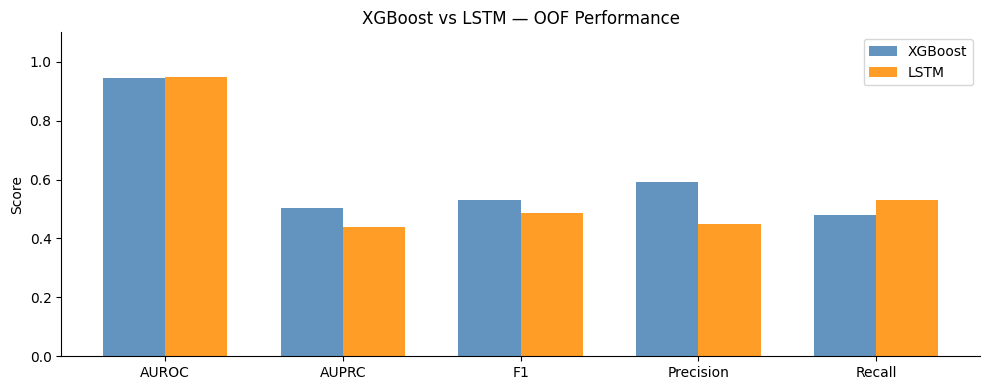

In [33]:
xgb_results = {
    "Model"      : "XGBoost (baseline)",
    "AUROC"      : 0.9451,
    "AUPRC"      : 0.5024,
    "F1"         : 0.5294,
    "Precision"  : 0.5902,
    "Recall"     : 0.4799,
    "Specificity": 0.9929,
}

lstm_results = {
    "Model"      : "LSTM (this notebook)",
    "AUROC"      : round(oof_auroc, 4),
    "AUPRC"      : round(oof_auprc, 4),
    "F1"         : round(oof_f1, 4),
    "Precision"  : round(oof_prec, 4),
    "Recall"     : round(oof_rec, 4),
    "Specificity": round(oof_spec, 4),
}

compare_df = pd.DataFrame([xgb_results, lstm_results])
print("Model Comparison (OOF, patient-level 5-fold CV)")
print("="*70)
print(compare_df.set_index("Model").to_string())

fig, ax = plt.subplots(figsize=(10, 4))
metrics  = ["AUROC", "AUPRC", "F1", "Precision", "Recall"]
x        = np.arange(len(metrics))
width    = 0.35

ax.bar(x - width/2, [xgb_results[m]  for m in metrics], width,
       label="XGBoost", color="steelblue", alpha=0.85)
ax.bar(x + width/2, [lstm_results[m] for m in metrics], width,
       label="LSTM",    color="darkorange", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("XGBoost vs LSTM — OOF Performance")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "lstm_vs_xgb.png"), dpi=150)
plt.show()


## 14. Confusion matrix

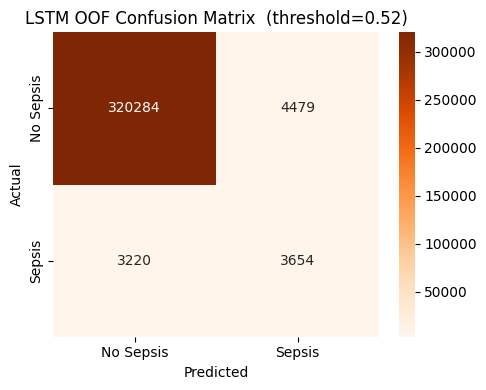

In [34]:
cm = confusion_matrix(oof_labels_lstm, oof_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Sepsis", "Sepsis"],
            yticklabels=["No Sepsis", "Sepsis"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"LSTM OOF Confusion Matrix  (threshold={best_thresh:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "lstm_confusion_matrix.png"), dpi=150)
plt.show()


## 15. Save OOF predictions

In [35]:
oof_df_lstm.to_parquet(os.path.join(SAVE_PATH, "oof_lstm.parquet"), index=False)
results_df.to_csv(os.path.join(SAVE_PATH, "fold_results_lstm.csv"), index=False)

# Save best fold index for the TFT notebook
best_fold_idx = int(np.argmax([m["AUPRC"] for m in fold_metrics]))
print(f"Saved:")
print(f"  oof_lstm.parquet")
print(f"  fold_results_lstm.csv")
print(f"  lstm_fold1_best.pt  through  lstm_fold{N_FOLDS}_best.pt")
print(f"\nBest fold: Fold {best_fold_idx+1}  (AUPRC={fold_metrics[best_fold_idx]['AUPRC']:.4f})")
print(f"Global best threshold: {best_thresh:.3f}")


Saved:
  oof_lstm.parquet
  fold_results_lstm.csv
  lstm_fold1_best.pt  through  lstm_fold5_best.pt

Best fold: Fold 3  (AUPRC=0.6842)
Global best threshold: 0.520


## Summary

| Metric | XGBoost | LSTM | Change |
|---|---|---|---|
| AUROC | 0.9451 | *see output* | — |
| AUPRC | 0.5024 | *see output* | — |
| F1 | 0.5294 | *see output* | — |
| Recall | 0.4799 | *see output* | — |

**What LSTM adds over XGBoost**
- Sees the temporal trajectory — rising lactate over 6 hours matters differently than a single high reading
- Bidirectionality helps on historical context; padding + packing handles variable ICU stay lengths cleanly
- Focal Loss focuses gradient on hard minority class examples instead of flooding with easy negatives

**Known limitation**
- Drug flags are still severity markers, not early warnings — the TFT in notebook 05 adds  
  multi-horizon forecasting to explicitly predict sepsis onset N hours ahead

---

## Next notebook

| # | Notebook | What it covers |
|---|---|---|
| 05 | `05_tft.ipynb` | Temporal Fusion Transformer — attention over time, multi-horizon prediction, N-hour-ahead early warning |
